# Darkstore Fabric Evaluation Analysis

This notebook loads the benchmark CSV files produced by `evaluation/run_benchmark.py`, computes summary statistics, and writes publication-ready figures to `../figures/`.

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "analysis" else Path.cwd().resolve()
RESULTS_DIR = ROOT / "evaluation" / "results"
FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

latency = pd.read_csv(RESULTS_DIR / "latency.csv")
throughput = pd.read_csv(RESULTS_DIR / "throughput.csv")
scalability = pd.read_csv(RESULTS_DIR / "scalability.csv")
sla_accuracy = pd.read_csv(RESULTS_DIR / "sla_accuracy.csv")
block_times = pd.read_csv(RESULTS_DIR / "block_times.csv")
fault_tolerance = pd.read_csv(RESULTS_DIR / "fault_tolerance.csv")
execution_time = pd.read_csv(RESULTS_DIR / "execution_time.csv") if (RESULTS_DIR / "execution_time.csv").exists() else pd.DataFrame()
immutability = pd.read_csv(RESULTS_DIR / "immutability.csv") if (RESULTS_DIR / "immutability.csv").exists() else pd.DataFrame()

In [12]:
summary = {
    "latency_mean_ms": float(latency["duration_ms"].mean()) if not latency.empty else None,
    "latency_p95_ms": float(latency["duration_ms"].quantile(0.95)) if not latency.empty else None,
    "throughput_mean_tps": float(throughput["throughput_tps"].mean()) if not throughput.empty else None,
    "sla_accuracy": float(sla_accuracy["is_correct"].mean()) if not sla_accuracy.empty else None,
    "block_confirmation_mean_ms": float(block_times["block_confirmation_ms"].mean()) if not block_times.empty else None,
    "fault_tolerance_success_rate": float(fault_tolerance["success"].mean()) if not fault_tolerance.empty else None,
}
pd.Series(summary, name="value")

latency_mean_ms                 2160.397031
latency_p95_ms                  2229.848800
throughput_mean_tps                0.441160
sla_accuracy                       1.000000
block_confirmation_mean_ms      2122.902504
fault_tolerance_success_rate       0.142857
Name: value, dtype: float64

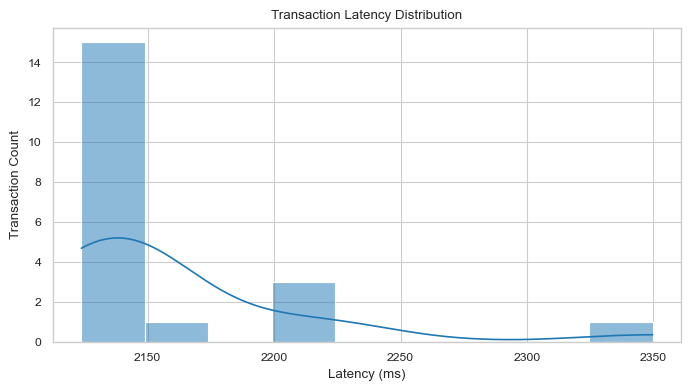

In [13]:
if not latency.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.histplot(data=latency, x="duration_ms", kde=True, ax=ax, color="#1f77b4")
    ax.set_title("Transaction Latency Distribution")
    ax.set_xlabel("Latency (ms)")
    ax.set_ylabel("Transaction Count")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "latency_plot.png", dpi=300, bbox_inches="tight")
    plt.show()

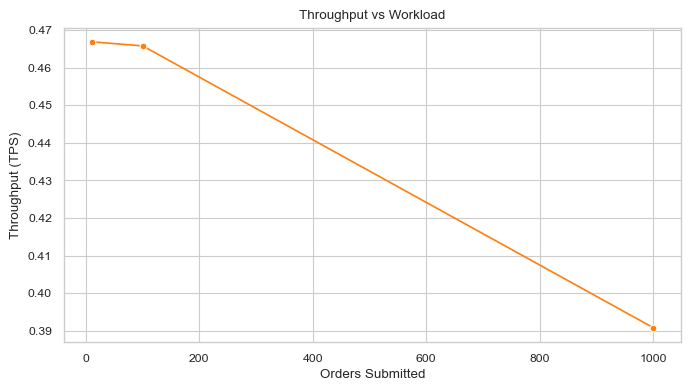

In [14]:
if not throughput.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.lineplot(data=throughput, x="workload_orders", y="throughput_tps", marker="o", ax=ax, color="#ff7f0e")
    ax.set_title("Throughput vs Workload")
    ax.set_xlabel("Orders Submitted")
    ax.set_ylabel("Throughput (TPS)")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "throughput_plot.png", dpi=300, bbox_inches="tight")
    plt.show()

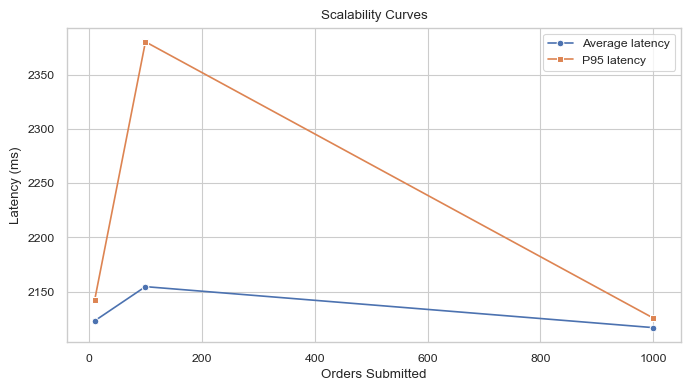

In [15]:
if not scalability.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.lineplot(data=scalability, x="workload_orders", y="avg_latency_ms", marker="o", label="Average latency", ax=ax)
    sns.lineplot(data=scalability, x="workload_orders", y="p95_latency_ms", marker="s", label="P95 latency", ax=ax)
    ax.set_title("Scalability Curves")
    ax.set_xlabel("Orders Submitted")
    ax.set_ylabel("Latency (ms)")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "scalability_plot.png", dpi=300, bbox_inches="tight")
    plt.show()

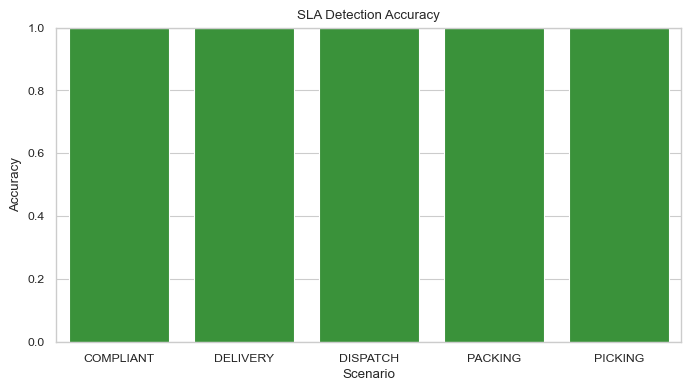

In [16]:
if not sla_accuracy.empty:
    accuracy_by_scenario = sla_accuracy.groupby("scenario", as_index=False)[["is_correct"]].mean()
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.barplot(data=accuracy_by_scenario, x="scenario", y="is_correct", ax=ax, color="#2ca02c")
    ax.set_title("SLA Detection Accuracy")
    ax.set_xlabel("Scenario")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "sla_accuracy_plot.png", dpi=300, bbox_inches="tight")
    plt.show()

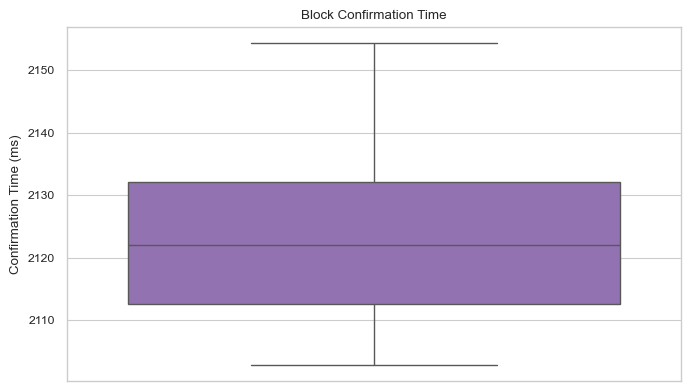

In [17]:
if not block_times.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.boxplot(data=block_times, y="block_confirmation_ms", ax=ax, color="#9467bd")
    ax.set_title("Block Confirmation Time")
    ax.set_ylabel("Confirmation Time (ms)")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "block_confirmation_plot.png", dpi=300, bbox_inches="tight")
    plt.show()

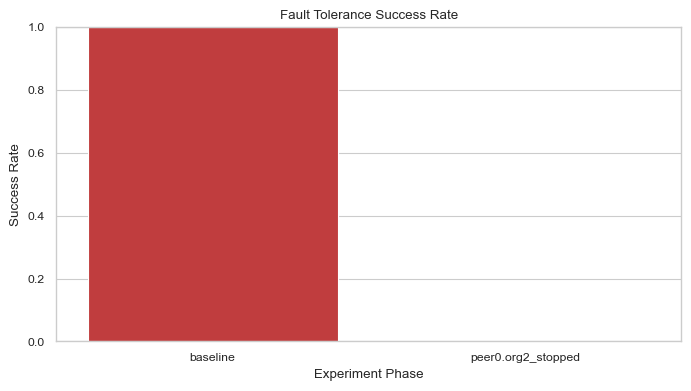

In [18]:
if not fault_tolerance.empty:
    success_rates = fault_tolerance.groupby("phase", as_index=False)["success"].mean()
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.barplot(data=success_rates, x="phase", y="success", ax=ax, color="#d62728")
    ax.set_title("Fault Tolerance Success Rate")
    ax.set_xlabel("Experiment Phase")
    ax.set_ylabel("Success Rate")
    ax.set_ylim(0, 1)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "fault_tolerance_plot.png", dpi=300, bbox_inches="tight")
    plt.show()

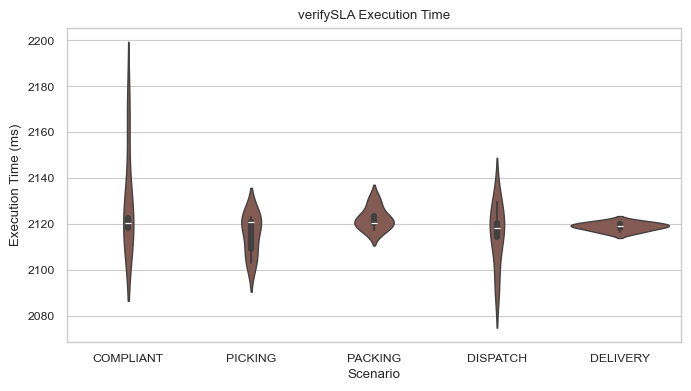

In [19]:
if not execution_time.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.violinplot(data=execution_time, x="scenario", y="duration_ms", ax=ax, color="#8c564b")
    ax.set_title("verifySLA Execution Time")
    ax.set_xlabel("Scenario")
    ax.set_ylabel("Execution Time (ms)")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "verify_execution_plot.png", dpi=300, bbox_inches="tight")
    plt.show()

In [20]:
if not immutability.empty:
    immutability